# Project Horizon

Project Horizon is a fictional game. All user-level and event-level data in this repository are synthetically generated for portfolio demonstration purposes. No proprietary, confidential, or real player data are used.

In [1]:
from pathlib import Path
import json, pandas as pd, sys
from IPython.display import display, Image
root=Path.cwd()
if not (root/'outputs').exists(): root=root.parent
sys.path.insert(0,str(root))
from python_src.database import query
s=json.loads((root/'outputs/executive_summary.json').read_text(encoding='utf8'))
assert query('SELECT count(*) FROM horizon.users').iloc[0,0]==s['users']
assert s['parity']['status']=='PASS'
display(s)

{'users': 200000,
 'simulation_days': 180,
 'seed': 20261005,
 'overall_d1': 0.320561420466273,
 'overall_d7': 0.17005398705991093,
 'overall_d30': 0.10438152384524033,
 'activation_rate': 0.8875409629442904,
 'activation_definition': 'D7 core-loop unlock: D0-D7 unlock among mature D7 registrations',
 'largest_core_funnel_drop': 'chapter_2',
 'largest_core_funnel_drop_fraction': 0.2809079182494882,
 'largest_optional_adoption_drop': 'social_interaction',
 'highest_risk_device': 'Android',
 'device_d7_gap': 0.0329625497919529,
 'chapter3_completion_given_chapter2': 0.7264334145217562,
 'chapter3_gate_level': 12,
 'chapter3_gate_failure_rate': 0.6267082741357147,
 'top_churn_signals': ['active_days_d0_7',
  'chapter_reached_d7',
  'sessions_d0_7',
  'activity_participation_d0_7',
  'avg_session_minutes'],
 'churn_signal_families': ['早期活跃强度', '主线进度', 'activity_participation_d0_7'],
 'model_auc': 0.6839645854953073,
 'model_pr_auc': 0.7700623264891899,
 'model_brier': 0.2161033672616404,
 

## Mature retention

In [2]:
display(pd.read_csv(root/'outputs/tables/retention_curve.csv').head(12))

,d,eligible,retained,rate,ci_low,ci_high
0,0,200000,200000,1.000000,0.999981,1.000000
1,1,198639,63676,0.320561,0.318513,0.322617
2,2,197331,53136,0.269273,0.267321,0.271235
3,3,195916,46080,0.235203,0.233330,0.237086
4,4,194526,40885,0.210178,0.208373,0.211994
5,5,193130,37260,0.192927,0.191173,0.194693
6,6,191810,34540,0.180074,0.178361,0.181800
7,7,190416,32381,0.170054,0.168373,0.171748
8,8,189108,30685,0.162262,0.160607,0.163930
9,9,187721,29246,0.155795,0.154162,0.157443


## Core funnel

In [3]:
display(pd.read_csv(root/'outputs/tables/core_funnel.csv').head(12))

,dimension,category,step,name,stage_type,n,denominator,conversion,dropoff,overall_conversion,ci_low,ci_high
0,channel,creator,1,Register,core,32405,32405,1.000000,0.000000,1.000000,0.999881,1.000000
1,channel,creator,2,tutorial_start,core,32405,32405,1.000000,0.000000,1.000000,0.999881,1.000000
2,channel,creator,3,tutorial_complete,core,30767,32405,0.949452,0.050548,0.949452,0.947013,0.951785
3,channel,creator,4,core_loop_unlock,core,28892,30767,0.939058,0.060942,0.891591,0.936330,0.941677
4,channel,creator,5,chapter_2,core,20882,28892,0.722761,0.277239,0.644407,0.717570,0.727892
5,channel,creator,6,chapter_3,core,15234,20882,0.729528,0.270472,0.470113,0.723461,0.735510
6,channel,cross_promo,1,Register,core,23052,23052,1.000000,0.000000,1.000000,0.999833,1.000000
7,channel,cross_promo,2,tutorial_start,core,23052,23052,1.000000,0.000000,1.000000,0.999833,1.000000
8,channel,cross_promo,3,tutorial_complete,core,21852,23052,0.947944,0.052056,0.947944,0.945001,0.950737
9,channel,cross_promo,4,core_loop_unlock,core,20466,21852,0.936573,0.063427,0.887819,0.933264,0.939729


## Optional adoption: Chapter3 denominator

In [4]:
display(pd.read_csv(root/'outputs/tables/optional_adoption.csv').head(12))

,dimension,category,step,name,stage_type,n,denominator,conversion,dropoff,overall_conversion,ci_low,ci_high
0,channel,creator,7,activity_enter,optional,12462,15234,0.818039,0.181961,0.384570,0.811832,0.824085
1,channel,creator,8,social_interaction,optional,6556,15234,0.430353,0.569647,0.202314,0.422509,0.438232
2,channel,cross_promo,7,activity_enter,optional,8649,10673,0.810363,0.189637,0.375195,0.802814,0.817688
3,channel,cross_promo,8,social_interaction,optional,4590,10673,0.430057,0.569943,0.199115,0.420691,0.439473
4,channel,organic,7,activity_enter,optional,14612,17879,0.817272,0.182728,0.384284,0.811539,0.822868
5,channel,organic,8,social_interaction,optional,7574,17879,0.423625,0.576375,0.199190,0.416400,0.430884
6,channel,referral,7,activity_enter,optional,6625,8061,0.821858,0.178142,0.388222,0.813353,0.830057
7,channel,referral,8,social_interaction,optional,4144,8061,0.514080,0.485920,0.242836,0.503165,0.524982
8,channel,store_feature,7,activity_enter,optional,7189,8744,0.822164,0.177836,0.376033,0.814008,0.830036
9,channel,store_feature,8,social_interaction,optional,3702,8744,0.423376,0.576624,0.193640,0.413056,0.433764


## Level / gate diagnosis

In [5]:
display(pd.read_csv(root/'outputs/tables/progression_diagnosis.csv').head(12))

,level,attempts,failures,users,failure_rate
0,12,236496,148214,121528,0.626708


## Observable multi-session features

In [6]:
display(pd.read_csv(root/'outputs/tables/python_features.csv').head(12))

,user_id,sessions_d0_7,active_days_d0_7,total_minutes_d0_7,avg_session_minutes,crash_rate_d0_7,fps_quality,max_feature_day,chapter_reached_d7,tutorial_completed,...,spend_d0_7,first_purchase_flag_d0_7,register_date,market,channel,device,campaign,registration_day,registration_week,churn_30
0,2,4,2,116.565387,29.141347,0.0,1.00,1.0,2,1,...,0.0,0,2026-02-07,KR,video_ads,Android,video_ads_1,37,5,1
1,3,1,1,48.387376,48.387376,0.0,2.00,0.0,0,0,...,0.0,0,2026-04-28,US,referral,Android,referral_3,117,16,1
2,4,1,1,51.848682,51.848682,0.0,3.00,0.0,1,1,...,0.0,0,2026-05-23,DE,video_ads,iOS,video_ads_3,142,20,1
3,5,8,5,238.895413,29.861927,0.0,2.00,5.0,3,1,...,0.0,0,2026-05-11,US,video_ads,iOS,video_ads_1,130,18,0
4,6,3,2,119.381930,39.793977,0.0,3.00,2.0,2,1,...,0.0,0,2026-02-24,JP,video_ads,PC,video_ads_2,54,7,1
5,7,2,2,87.670521,43.835260,0.0,2.00,3.0,2,1,...,0.0,0,2026-05-18,DE,store_feature,Android,store_feature_1,137,19,1
6,9,1,1,46.450587,46.450587,0.0,2.00,0.0,1,1,...,0.0,0,2026-03-15,DE,video_ads,Android,video_ads_3,73,10,1
7,10,1,1,54.627192,54.627192,0.0,2.00,0.0,0,1,...,0.0,0,2026-05-20,US,creator,Android,creator_1,139,19,1
8,11,2,1,48.213426,24.106713,0.0,2.00,0.0,1,1,...,0.0,0,2026-01-06,DE,store_feature,iOS,store_feature_2,5,0,1
9,12,4,3,191.370659,47.842665,0.0,2.25,4.0,2,1,...,0.0,0,2026-04-27,DE,cross_promo,PC,cross_promo_3,116,16,0


## Correlated signal families

In [7]:
display(pd.read_csv(root/'outputs/tables/feature_correlations.csv').head(12))

,Unnamed: 0,sessions_d0_7,active_days_d0_7,total_minutes_d0_7,avg_session_minutes
0,sessions_d0_7,1.000000,0.911092,0.889001,-0.304062
1,active_days_d0_7,0.911092,1.000000,0.952902,-0.030540
2,total_minutes_d0_7,0.889001,0.952902,1.000000,0.100539
3,avg_session_minutes,-0.304062,-0.030540,0.100539,1.000000


## Logistic interpretation

In [8]:
display(pd.read_csv(root/'outputs/tables/python_logistic_coefficients.csv').head(12))

,feature,coefficient,odds_ratio_per_sd
0,sessions_d0_7,0.205522,1.228166
1,active_days_d0_7,-0.638640,0.528010
2,total_minutes_d0_7,-0.099687,0.905121
3,avg_session_minutes,0.119076,1.126456
4,tutorial_completed,0.005020,1.005033
5,core_loop_unlocked,0.096642,1.101466
6,chapter_reached_d7,-0.299952,0.740854
7,boss_attempts_d0_7,0.062998,1.065025
8,boss_failure_rate_d0_7,-0.056113,0.945433
9,social_interactions_d0_7,-0.024059,0.976228


## Segments

In [9]:
display(pd.read_csv(root/'outputs/tables/python_segments.csv').head(12))

,segment,n,active_days28,minutes28,chapter,payer_rate,d30_retention_mature,recommended_action
0,At-Risk Users,141950,0.792990,40.064883,2.491011,0.026904,0.077226,按可观测风险与成本排序触达
1,Core Engaged Users,25466,6.381960,326.838870,3.492735,0.079321,0.196154,维持内容节奏与社交可达性
2,Healthy New Users,7752,1.908927,97.093285,1.803922,0.005418,NaN,强化核心循环与内容匹配
3,High-Value Users,27,5.777778,333.305677,5.555556,1.000000,0.407407,稳定体验与内容服务
4,Highly Engaged Non-Payers,7595,11.345754,628.351582,4.299013,0.000000,0.280548,内容推荐，避免强制付费压力
5,New & Unactivated,1832,1.157751,56.377944,0.000000,0.001638,NaN,检查引导与首次核心循环触达
6,Returning Users,15378,5.366823,268.398726,3.472558,0.047210,0.174904,个性化回流导航并开展随机实验


## Gate experiment & power

In [10]:
display(pd.read_csv(root/'outputs/tables/experiment_design.csv').head(12))

,experiment,population,primary,eligible_n,completed_n,baseline,mde,per_arm,treatment,guardrails
0,A,First Level 12 boss attempt; user 1:1 randomiz...,Chapter 3 completion within 3 days of first Le...,151582,106257.0,0.700987,0.025,5133,关卡难度、资源或引导优化,"Mature D7/D14 retention, crashes, playtime, sp..."
1,B,Top decile risk ranked at D7,Exact-day D30 retention,4087,NaN,0.037436,0.030,850,个性化任务提示与资源扶持,"Crashes, spend, opt-out; D22-D30 activity seco..."
2,C,14-day silent users randomized at observed return,Post-return D0-D6 active days,10140,NaN,2.550592,0.300,235,个性化回流内容导航,"Crashes, disengagement, spend"


## Corrected evaluation and session semantics
D7 core-loop unlock uses D0-D7 events; distinct from exact D7 retention. Threshold0.5 is diagnostic, ranking respects the budget.

,sessions_d0_7,active_days_d0_7
count,159990.000000,159990.000000
mean,3.442734,2.579342
std,1.971388,1.323385
min,1.000000,1.000000
25%,2.000000,1.000000
50%,3.000000,2.000000
75%,5.000000,3.000000
max,16.000000,8.000000


{'logistic': {'roc_auc': 0.6839645854953073,
  'pr_auc': 0.7700623264891899,
  'brier': 0.2161033672616404,
  'precision': 0.6585834409347149,
  'recall': 0.8433958459366808,
  'f1': 0.7396194383532575,
  'confusion_matrix': [[5234, 10841], [3883, 20912]],
  'threshold': 0.5,
  'lift_at_10pct': 1.4414196410566646,
  'capture_at_10pct': 0.14414196410566646},
 'nonlinear': {'roc_auc': 0.6842591978955271,
  'pr_auc': 0.7697870558106377,
  'brier': 0.21478271789120287,
  'precision': 0.6732757738115551,
  'recall': 0.7956846138334341,
  'f1': 0.7293800140485786,
  'confusion_matrix': [[6501, 9574], [5066, 19729]],
  'threshold': 0.5,
  'lift_at_10pct': 1.442226255293406,
  'capture_at_10pct': 0.1442226255293406},
 'train_n': 85045,
 'validation_n': 34075,
 'test_n': 40870,
 'nonlinear_train_n': 30000,
 'feature_names': ['sessions_d0_7',
  'active_days_d0_7',
  'total_minutes_d0_7',
  'avg_session_minutes',
  'tutorial_completed',
  'core_loop_unlocked',
  'chapter_reached_d7',
  'boss_atte

{'logistic': {'roc_auc': 0.6839645905131253,
  'pr_auc': 0.7700623459399804,
  'brier': 0.21610336734793562,
  'precision': 0.6585834409347149,
  'recall': 0.8433958459366808,
  'f1': 0.7396194383532574,
  'confusion_matrix': [[5234, 10841], [3883, 20912]],
  'threshold': 0.5,
  'lift_at_10pct': 1.4414196410566646,
  'capture_at_10pct': 0.14414196410566646},
 'nonlinear': {'roc_auc': 0.6824101959551997,
  'pr_auc': 0.7687324786366369,
  'brier': 0.2149339184399367,
  'precision': 0.6814133765999639,
  'recall': 0.7622101230086711,
  'f1': 0.719550732914525,
  'confusion_matrix': [[7239, 8836], [5896, 18899]],
  'threshold': 0.5,
  'lift_at_10pct': 1.4406130268199233,
  'capture_at_10pct': 0.14406130268199233},
 'train_n': 85045,
 'validation_n': 34075,
 'test_n': 40870,
 'nonlinear_train_n': 30000,
 'feature_names': ['sessions_d0_7',
  'active_days_d0_7',
  'total_minutes_d0_7',
  'avg_session_minutes',
  'tutorial_completed',
  'core_loop_unlocked',
  'chapter_reached_d7',
  'boss_att

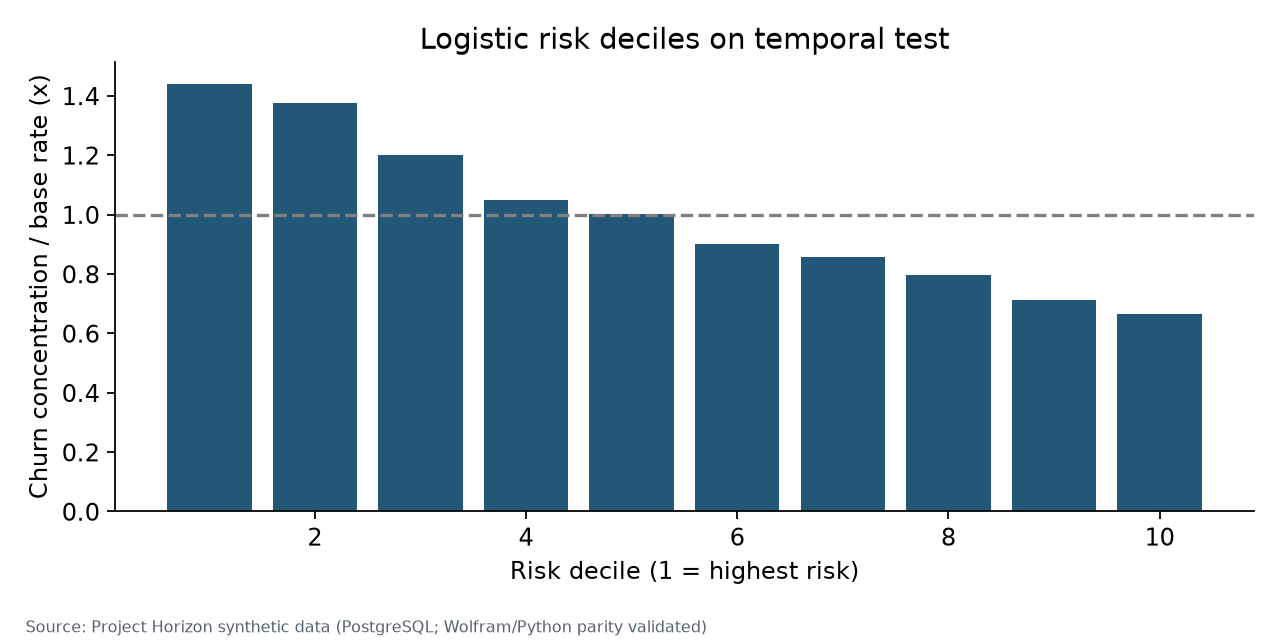

In [11]:
f=pd.read_csv(root/'outputs/tables/python_features.csv')
assert (f.sessions_d0_7>=f.active_days_d0_7).all()
display(f[['sessions_d0_7','active_days_d0_7']].describe())
for runtime in ['wolfram','python']:
    em=json.loads((root/f'outputs/models/{runtime}_evaluation.json').read_text())
    assert sum(map(sum,em['logistic']['confusion_matrix']))==em['test_n']
    display(em)
display(Image(filename=str(root/'outputs/figures/python/14_risk_decile_lift.png')))